# Exploratory Data Analysis (EDA)

## Objetivo:
Explorar la composición del microbioma intestinal, la distribución de condiciones clínicas y posibles sesgos asociados a metadata como país, estudio, edad, género y BMI.

## 0. Importar librerías

In [14]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns


## 1. Cargar datos limpios

In [9]:
df_eda = pd.read_csv("D:/BOOTCAMP/CARPETA_BARBARA/ML_MICROBIOME/ML/data/processed/abundance_stoolsubset_clean.csv",
    low_memory=False
)

df_eda.shape

(1577, 2135)

## 2. Vista general del dataset

In [10]:
metadata_cols = [
    "dataset_name",
    "sampleID",
    "disease",
    "age",
    "gender",
    "country",
    "bmi"
]

taxa_cols = [col for col in df_eda.columns if col.startswith("k__")]

print("Número de muestras:", df_eda.shape[0])
print("Número de columnas totales:", df_eda.shape[1])
print("Número de columnas metadata:", len(metadata_cols))
print("Número de columnas taxonómicas:", len(taxa_cols))

Número de muestras: 1577
Número de columnas totales: 2135
Número de columnas metadata: 7
Número de columnas taxonómicas: 2128


In [11]:
df_eda[metadata_cols].isna().sum().sort_values(ascending=False)

age             356
bmi             331
dataset_name      0
disease           0
sampleID          0
gender            0
country           0
dtype: int64

In [12]:
df_eda["sampleID"].duplicated().sum()

np.int64(0)

In [13]:
df_eda["disease"].value_counts(dropna=False)

disease
n                             710
t2d                           223
ibd_ulcerative_colitis        148
cirrhosis                     118
obesity                        75
impaired_glucose_tolerance     49
cancer                         48
n_relative                     47
stec2-positive                 43
leanness                       42
small_adenoma                  26
ibd_crohn_disease              25
large_adenoma                  13
overweight                     10
Name: count, dtype: int64

El dataset limpio contiene **1577 muestras únicas**, sin sampleID duplicados y con **2128 variables taxonómicas**. La variable `disease` no presenta valores nulos, aunque `age` y `bmi` conservan valores faltantes, por lo que inicialmente se utilizarán como **variables descriptivas** y no como predictores principales.

## 3. Distribución de las enfermedades

In [44]:
# Conteo y porcentaje por enfermedad
disease_counts = df_eda["disease"].value_counts().sort_values(ascending=False)
disease_percentages = disease_counts / disease_counts.sum() * 100

In [45]:
# DataFrame - conteo y porcentaje por enfermedad
disease_distribution = pd.DataFrame({
    "count": disease_counts,
    "percentage": disease_percentages.round(2)
})

disease_distribution

,count,percentage
disease,,
n,710,45.02
t2d,223,14.14
ibd_ulcerative_colitis,148,9.38
cirrhosis,118,7.48
obesity,75,4.76
impaired_glucose_tolerance,49,3.11
cancer,48,3.04
n_relative,47,2.98
stec2-positive,43,2.73


In [46]:
### Paleta de colores

# Paleta general del proyecto
project_palette = {
    "primary": "#2F5D62",
    "secondary": "#5E8B7E",
    "accent": "#D88C3A",
    "danger": "#B85750",
    "neutral": "#6B7280",
    "light": "#F3F4F6",
    "dark": "#1F2937"
}

# Paleta específica para "disease"
disease_palette = {
    "n": "#2F5D62",
    "t2d": "#D88C3A",
    "ibd_ulcerative_colitis": "#7A5195",
    "cirrhosis": "#B85750",
    "obesity": "#5E8B7E",
    "impaired_glucose_tolerance": "#E0A458",
    "cancer": "#4C78A8",
    "n_relative": "#8C8C8C",
    "stec2-positive": "#C44E52",
    "leanness": "#76B7B2",
    "small_adenoma": "#9C755F",
    "ibd_crohn_disease": "#59A14F",
    "large_adenoma": "#AF7AA1",
    "overweight": "#F28E2B"
}

C:\Users\gonza\AppData\Local\Temp\ipykernel_11700\3968542494.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


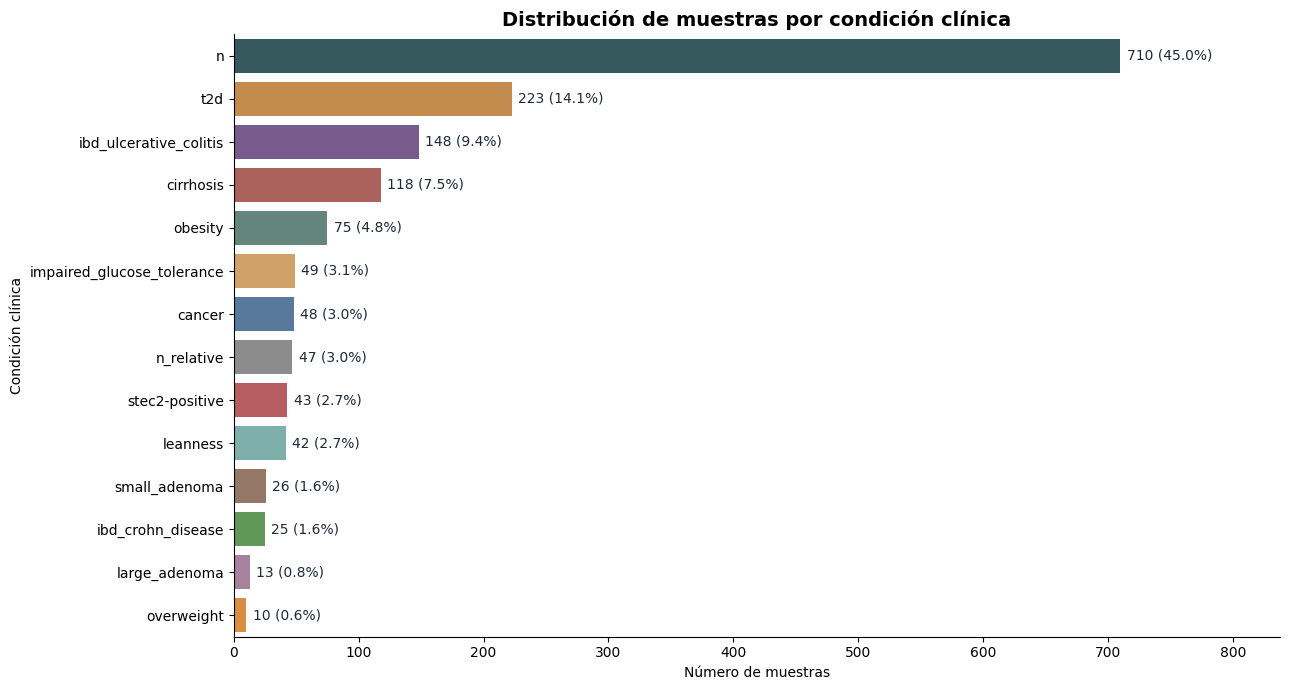

In [49]:
## Gráfico de barras - distribución de enfermedades
plt.figure(figsize=(13, 7))

bar_colors = [
    disease_palette.get(disease, project_palette["neutral"])
    for disease in disease_counts.index
]

ax = sns.barplot(
    x=disease_counts.values,
    y=disease_counts.index,
    palette=bar_colors
)

for i, (count, pct) in enumerate(zip(disease_counts.values, disease_percentages.values)):
    ax.text(
        count + 5,
        i,
        f"{count} ({pct:.1f}%)",
        va="center",
        fontsize=10,
        color=project_palette["dark"]
    )

plt.title("Distribución de muestras por condición clínica", fontsize=14, fontweight="bold")
plt.xlabel("Número de muestras")
plt.ylabel("Condición clínica")
plt.xlim(0, disease_counts.max() * 1.18)

sns.despine()
plt.tight_layout()

# Guardar gráfico
plt.savefig(
    f"D:/BOOTCAMP/CARPETA_BARBARA/ML_MICROBIOME/ML/docs/figures/muestra_condicion.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

La variable `disease` presenta una distribución desbalanceada. 
<br>
La clase mayoritaria es `n`, correspondiente a controles, seguida por `t2d`, `ibd_ulcerative_colitis`, `cirrhosis` y `obesity`.
<br>
Algunas categorías tienen muy pocas muestras, como `large_adenoma` y `overweight`, por lo que se conservarán para EDA general pero no se consideran candidatas principales para el modelado supervisado inicial.

## 4. Análisis de metadata clínica

### 4.1. Distribución de metadata clínica: `age` y `bmi`

In [52]:
numeric_metadata = ["age", "bmi"]

df_eda[numeric_metadata].describe()

,age,bmi
count,1221.000000,1246.000000
mean,48.964955,24.534551
std,16.445743,4.665831
min,2.000000,14.050000
25%,37.000000,21.000000
50%,49.000000,24.000000
75%,63.000000,26.875000
max,89.000000,46.600000


In [ ]:
# Porcentaje de valores nulos en "age" y "bmi"
missing_numeric_metadata = (
    df_eda[numeric_metadata]
    .isna()
    .mean()
    .mul(100)
    .round(2)
)

missing_numeric_metadata

age    22.57
bmi    20.99
dtype: float64

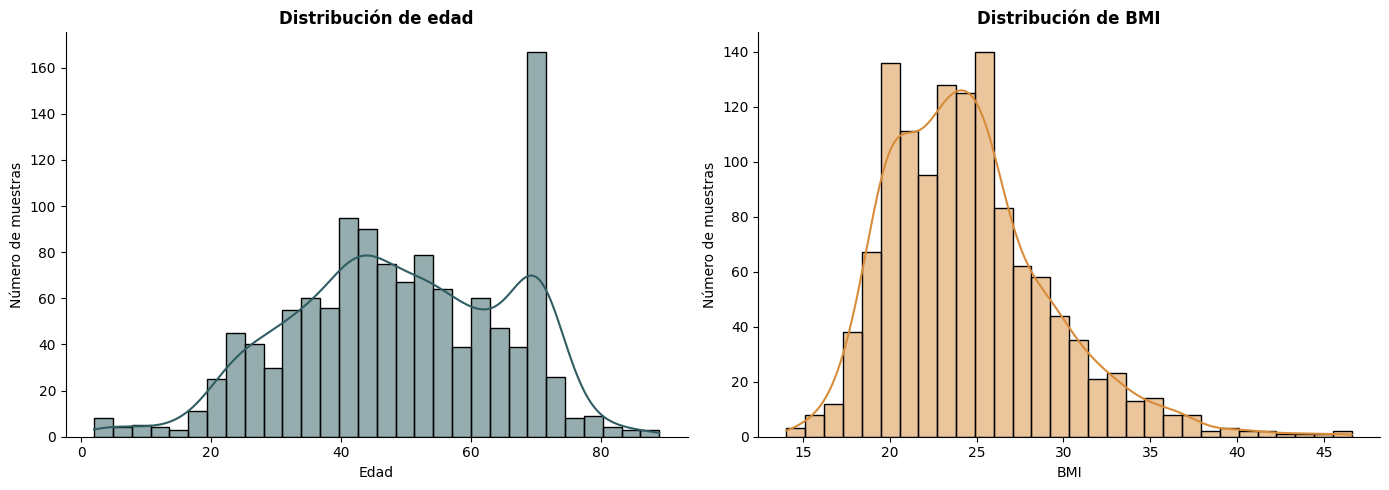

In [51]:
# Distribución general de "age" y "bmi"
fig, axes = plt.subplots(1, 2, figsize=(14, 5))     # dos gráficos en una fila

# Age
sns.histplot(
    data=df_eda,
    x="age",
    bins=30,        # 30 grupos
    kde=True,       # curva suave de densidad
    color=project_palette["primary"],
    ax=axes[0]
)

axes[0].set_title("Distribución de edad", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Edad")
axes[0].set_ylabel("Número de muestras")

# BMI
sns.histplot(
    data=df_eda,
    x="bmi",
    bins=30,
    kde=True,
    color=project_palette["accent"],
    ax=axes[1]
)

axes[1].set_title("Distribución de BMI", fontsize=12, fontweight="bold")
axes[1].set_xlabel("BMI")
axes[1].set_ylabel("Número de muestras")

sns.despine()       # quit alos bordes visuales del gráfico
plt.tight_layout()  # evita que los textos y ejes se monten

# Guardar gráfico
plt.savefig(
    f"D:/BOOTCAMP/CARPETA_BARBARA/ML_MICROBIOME/ML/docs/figures/distr_edad_bmi.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [85]:
# Filtrar enfermedades con al menos 10 valores válidos de age

min_age_values = 10

valid_age_counts = df_eda.groupby("disease")["age"].count()

diseases_with_age = valid_age_counts[
    valid_age_counts >= min_age_values
].index

df_age_boxplot = df_eda[
    df_eda["disease"].isin(diseases_with_age)
].copy()

In [87]:
# Orden alfabético
age_order = sorted(df_age_boxplot["disease"].unique())

C:\Users\gonza\AppData\Local\Temp\ipykernel_11700\3620942095.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


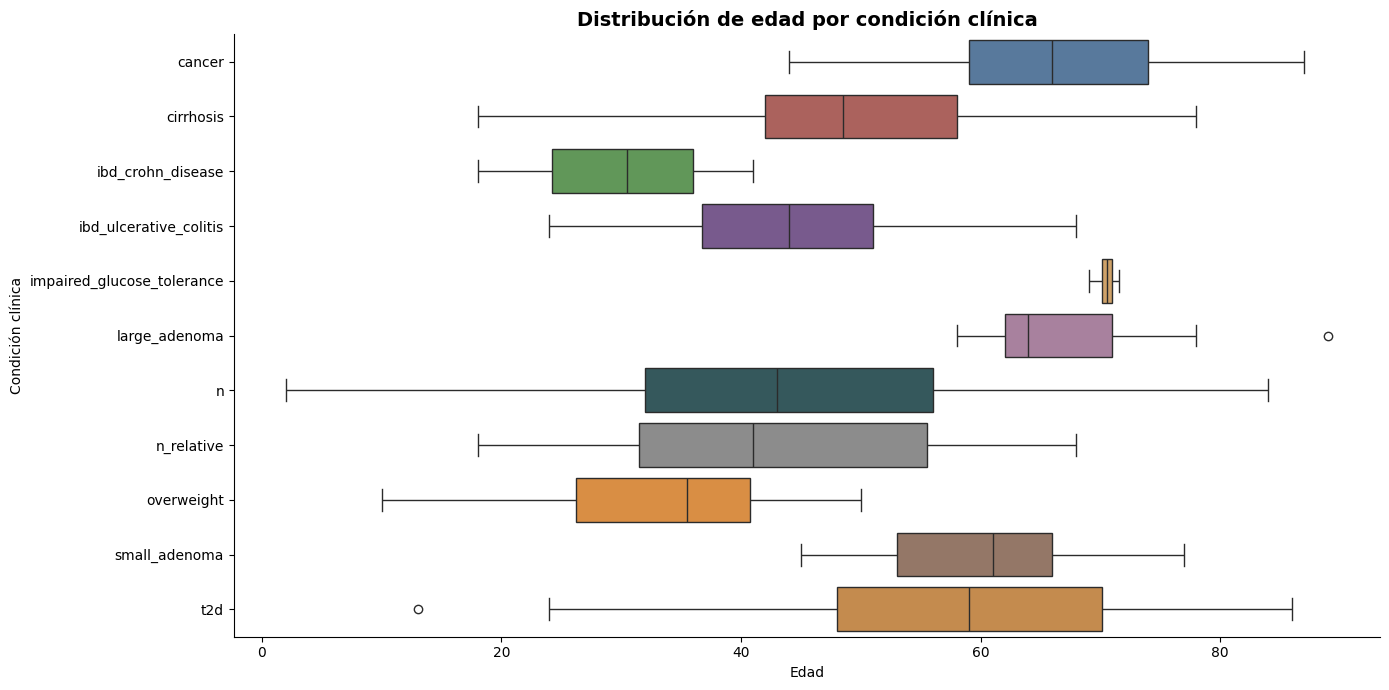

In [88]:
## Boxplot de edad por enfermedad
plt.figure(figsize=(14, 7))

bar_colors = [
    disease_palette.get(disease, project_palette["neutral"])
    for disease in age_order
]

sns.boxplot(
    data=df_age_boxplot,
    x="age",
    y="disease",
    order=age_order,
    palette=bar_colors
)

plt.title("Distribución de edad por condición clínica", fontsize=14, fontweight="bold")
plt.xlabel("Edad")
plt.ylabel("Condición clínica")

sns.despine()
plt.tight_layout()

# Guardar gráfico
plt.savefig(
    f"D:/BOOTCAMP/CARPETA_BARBARA/ML_MICROBIOME/ML/docs/figures/edad_condicion.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [80]:
# Filtrar enfermedades con al menos 10 valores válidos de BMI

min_bmi_values = 10

valid_bmi_counts = df_eda.groupby("disease")["bmi"].count()

diseases_with_bmi = valid_bmi_counts[
    valid_bmi_counts >= min_bmi_values
].index

df_bmi_boxplot = df_eda[
    df_eda["disease"].isin(diseases_with_bmi)
].copy()

In [ ]:
# Orden alfabético
bmi_order = sorted(df_bmi_boxplot["disease"].unique())


C:\Users\gonza\AppData\Local\Temp\ipykernel_11700\2353784519.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


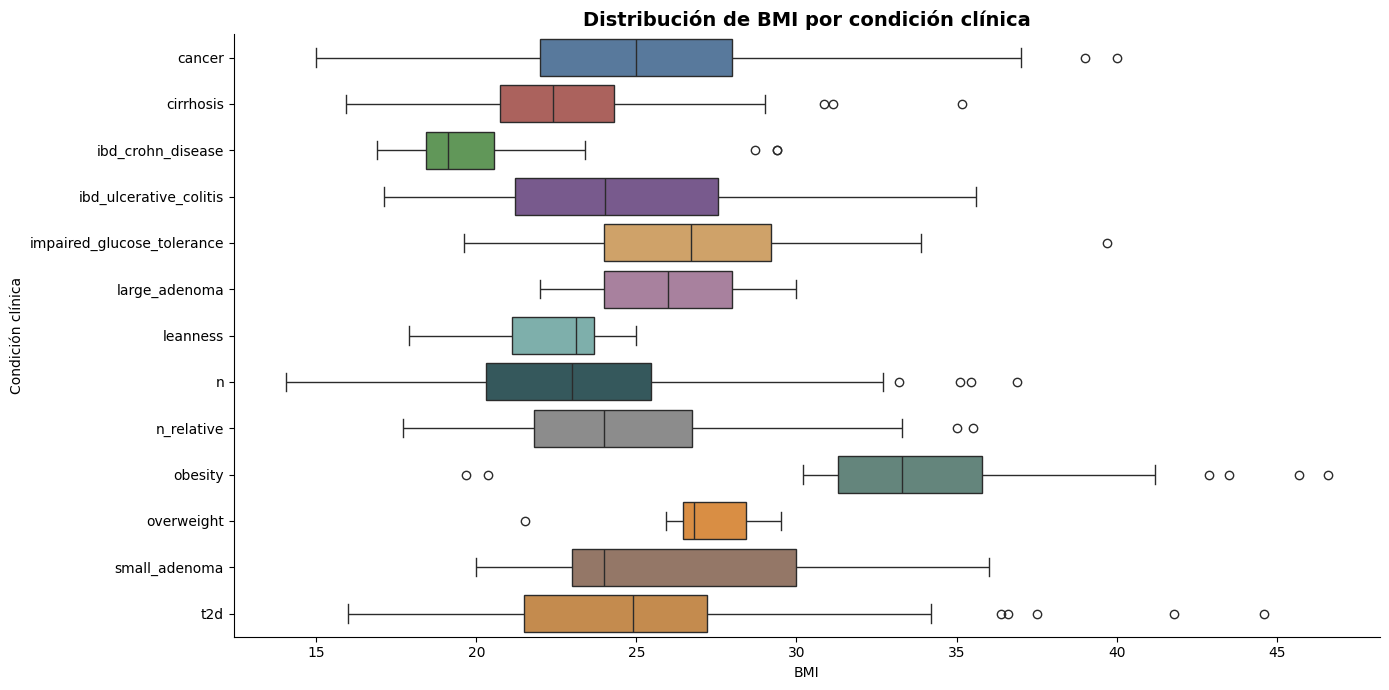

In [84]:
## Boxplot de BMI por enfermedad
plt.figure(figsize=(14, 7))

bar_colors = [
    disease_palette.get(disease, project_palette["neutral"])
    for disease in bmi_order
]

sns.boxplot(
    data=df_bmi_boxplot,
    x="bmi",
    y="disease",
    order=bmi_order,
    palette=bar_colors
)

plt.title("Distribución de BMI por condición clínica", fontsize=14, fontweight="bold")
plt.xlabel("BMI")
plt.ylabel("Condición clínica")

sns.despine()
plt.tight_layout()

# Guardar gráfico
plt.savefig(
    f"D:/BOOTCAMP/CARPETA_BARBARA/ML_MICROBIOME/ML/docs/figures/bmi_condicion.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 5. Distribución de metadata categórica

### 5.1. Distribución de metadata categórica: `gender`

In [53]:
# Conteo de muestras por categoria de "gender" (male/female/unknown)
gender_counts = df_eda["gender"].value_counts()

# Porcentaje que representa cada categoría
gender_percentages = gender_counts / gender_counts.sum() * 100

# DataFrame - conteo y porcentaje
gender_distribution = pd.DataFrame({
    "count": gender_counts,
    "percentage": gender_percentages.round(2)
})

gender_distribution

,count,percentage
gender,,
male,688,43.63
female,585,37.10
unknown,304,19.28


In [59]:
# Paleta de colores
gender_palette = {
    "female": "#2F5D62",
    "male": "#D88C3A",
    "unknown": "#8C8C8C"
}

C:\Users\gonza\AppData\Local\Temp\ipykernel_11700\3367694956.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


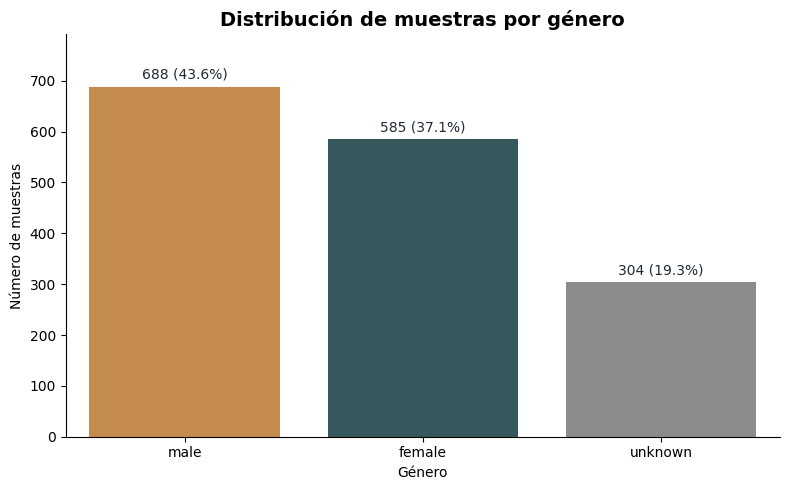

In [60]:
# Gráfico
plt.figure(figsize=(8, 5))

bar_colors = [
    gender_palette.get(gender, project_palette["neutral"])
    for gender in gender_counts.index
]

ax = sns.barplot(
    x=gender_counts.index,
    y=gender_counts.values,
    palette=bar_colors
)

for i, (count, pct) in enumerate(zip(gender_counts.values, gender_percentages.values)):
    ax.text(
        i,
        count + 10,
        f"{count} ({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10,
        color=project_palette["dark"]
    )

plt.title("Distribución de muestras por género", fontsize=14, fontweight="bold")
plt.xlabel("Género")
plt.ylabel("Número de muestras")
plt.ylim(0, gender_counts.max() * 1.15)

sns.despine()
plt.tight_layout()

plt.savefig(
    f"D:/BOOTCAMP/CARPETA_BARBARA/ML_MICROBIOME/ML/docs/figures/genero_distr",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 5.2. Distribución de metadata categórica: `country`

In [69]:
# Distribución por país: top 10 + "other" + "unknown"

country_counts = df_eda["country"].value_counts()

# Seleccionar top 10 países, excluyendo "unknown"
top_n_countries = 10

top_countries = (
    country_counts
    .drop(labels="unknown", errors="ignore")
    .head(top_n_countries)
    .index
    .tolist()
)

# Crear una columna auxiliar para el gráfico
df_eda["country_plot"] = df_eda["country"].where(
    df_eda["country"].isin(top_countries),
    "other"
)

# Mantener "unknown" separado, no dentro de "other"
df_eda.loc[df_eda["country"] == "unknown", "country_plot"] = "unknown"

# Conteos y porcentajes
country_plot_counts = df_eda["country_plot"].value_counts()

# Orden manual: top 10 países, luego "other", luego "unknown"
country_order = top_countries.copy()

if "other" in country_plot_counts.index:
    country_order.append("other")

if "unknown" in country_plot_counts.index:
    country_order.append("unknown")

country_plot_counts = country_plot_counts.loc[country_order]
country_plot_percentages = country_plot_counts / country_plot_counts.sum() * 100

In [70]:
# Paleta para países
country_palette_base = [
    project_palette["primary"],
    project_palette["secondary"],
    "#4C78A8",
    "#7A5195",
    "#76B7B2",
    "#E0A458",
    "#9C755F",
    "#59A14F",
    "#AF7AA1",
    "#F28E2B"
]

country_palette = {
    country: color
    for country, color in zip(top_countries, country_palette_base)
}

country_palette["other"] = project_palette["accent"]
country_palette["unknown"] = "#9CA3AF"

bar_colors = [
    country_palette.get(country, project_palette["neutral"])
    for country in country_plot_counts.index
]

C:\Users\gonza\AppData\Local\Temp\ipykernel_11700\2596293868.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


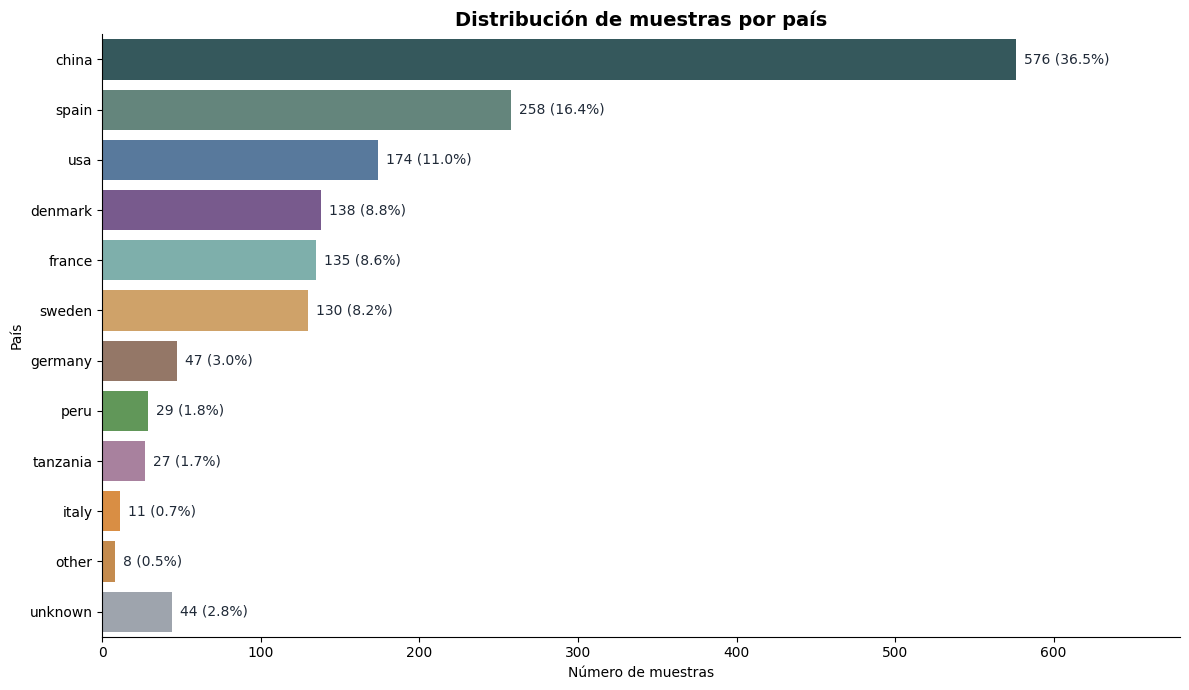

In [71]:
# Gráfico
plt.figure(figsize=(12, 7))

ax = sns.barplot(
    x=country_plot_counts.values,
    y=country_plot_counts.index,
    palette=bar_colors
)

for i, (count, pct) in enumerate(zip(country_plot_counts.values, country_plot_percentages.values)):
    ax.text(
        count + 5,
        i,
        f"{count} ({pct:.1f}%)",
        va="center",
        fontsize=10,
        color=project_palette["dark"]
    )

plt.title("Distribución de muestras por país", fontsize=14, fontweight="bold")
plt.xlabel("Número de muestras")
plt.ylabel("País")
plt.xlim(0, country_plot_counts.max() * 1.18)

sns.despine()
plt.tight_layout()

# Guardar gráfico
plt.savefig(
    f"D:/BOOTCAMP/CARPETA_BARBARA/ML_MICROBIOME/ML/docs/figures/country_distr.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 5.3. Distribución de metadata categórica: `dataset_name`

Observar si el dataset está dominado por ciertos estudios. Y eso importa muchísimo, porque si luego el PCA o el modelo separan por `dataset_name`, puedeb haber sesgo de origen.

In [72]:
# Distribución por dataset de origen

# Contar cuántas muestras vienen de cada "dataset_name"
dataset_counts = df_eda["dataset_name"].value_counts()

# Calcular porcentaje
dataset_percentages = dataset_counts / dataset_counts.sum() * 100

# Top 20 estudios/datasets principales
dataset_distribution = pd.DataFrame({
    "count": dataset_counts,
    "percentage": dataset_percentages.round(2)
})

dataset_distribution.head(20)

,count,percentage
dataset_name,,
t2dmeta_long,271,17.18
quin_gut_liver_cirrhosis,232,14.71
neilsen_genome_assembly,231,14.65
hmp,152,9.64
wt2d,145,9.19
zeller_fecal_colorectal_cancer,134,8.50
chatelier_gut_obesity,115,7.29
t2dmeta_short,73,4.63
tito_subsistence_gut,51,3.23


In [74]:
# Seleccionar los 10 datasets con más muestras
top_n_datasets = 10

top_datasets = dataset_counts.head(top_n_datasets).index.tolist()

df_eda["dataset_plot"] = df_eda["dataset_name"].where(
    df_eda["dataset_name"].isin(top_datasets),
    "other"
)

dataset_plot_counts = df_eda["dataset_plot"].value_counts()

dataset_order = top_datasets.copy()

if "other" in dataset_plot_counts.index:
    dataset_order.append("other")

dataset_plot_counts = dataset_plot_counts.loc[dataset_order]
dataset_plot_percentages = dataset_plot_counts / dataset_plot_counts.sum() * 100

C:\Users\gonza\AppData\Local\Temp\ipykernel_11700\107772168.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


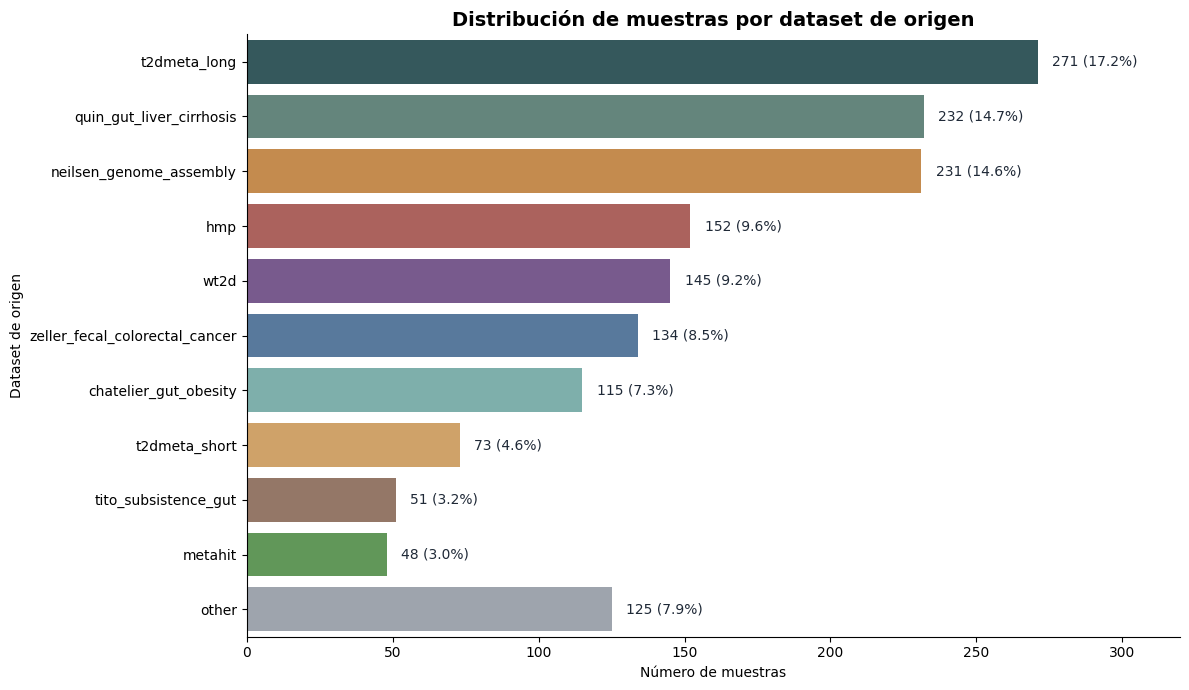

In [76]:
# Griafico
dataset_palette_base = [
    project_palette["primary"],
    project_palette["secondary"],
    project_palette["accent"],
    project_palette["danger"],
    "#7A5195",
    "#4C78A8",
    "#76B7B2",
    "#E0A458",
    "#9C755F",
    "#59A14F"
]

dataset_palette = {
    dataset: color
    for dataset, color in zip(top_datasets, dataset_palette_base)
}

dataset_palette["other"] = "#9CA3AF"

bar_colors = [
    dataset_palette.get(dataset, project_palette["neutral"])
    for dataset in dataset_plot_counts.index
]

plt.figure(figsize=(12, 7))

ax = sns.barplot(
    x=dataset_plot_counts.values,
    y=dataset_plot_counts.index,
    palette=bar_colors
)

for i, (count, pct) in enumerate(zip(dataset_plot_counts.values, dataset_plot_percentages.values)):
    ax.text(
        count + 5,
        i,
        f"{count} ({pct:.1f}%)",
        va="center",
        fontsize=10,
        color=project_palette["dark"]
    )

plt.title("Distribución de muestras por dataset de origen", fontsize=14, fontweight="bold")
plt.xlabel("Número de muestras")
plt.ylabel("Dataset de origen")
plt.xlim(0, dataset_plot_counts.max() * 1.18)

sns.despine()
plt.tight_layout()

# Guardar gráfico
plt.savefig(
    f"D:/BOOTCAMP/CARPETA_BARBARA/ML_MICROBIOME/ML/docs/figures/dataset_origin_distr_top10.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 6. Análisis general de taxones

### 6.1. Análisis general de taxones

In [ ]:
# Contar número de columnas taxonómicas
taxa_cols = [col for col in df_eda.columns if col.startswith("k__")]

print("Número de columnas taxonómicas:", len(taxa_cols))

Número de columnas taxonómicas: 2128


In [90]:
# Identificar niveles taxonómicos
def get_deepest_taxonomic_level(taxon_name):
    levels = taxon_name.split("|")
    deepest_level = levels[-1]
    return deepest_level.split("__")[0] + "__"

taxonomic_levels = pd.Series(
    [get_deepest_taxonomic_level(col) for col in taxa_cols]
)

taxonomic_level_counts = taxonomic_levels.value_counts()

taxonomic_level_counts

s__    826
t__    767
g__    292
f__    119
o__     60
c__     38
p__     23
k__      3
Name: count, dtype: int64

In [92]:
# Definir paleta de colores
taxonomic_level_palette = {
    "k__": "#2F5D62",
    "p__": "#5E8B7E",
    "c__": "#76B7B2",
    "o__": "#4C78A8",
    "f__": "#7A5195",
    "g__": "#D88C3A",
    "s__": "#B85750",
    "t__": "#9C755F"
}

C:\Users\gonza\AppData\Local\Temp\ipykernel_11700\2810565461.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


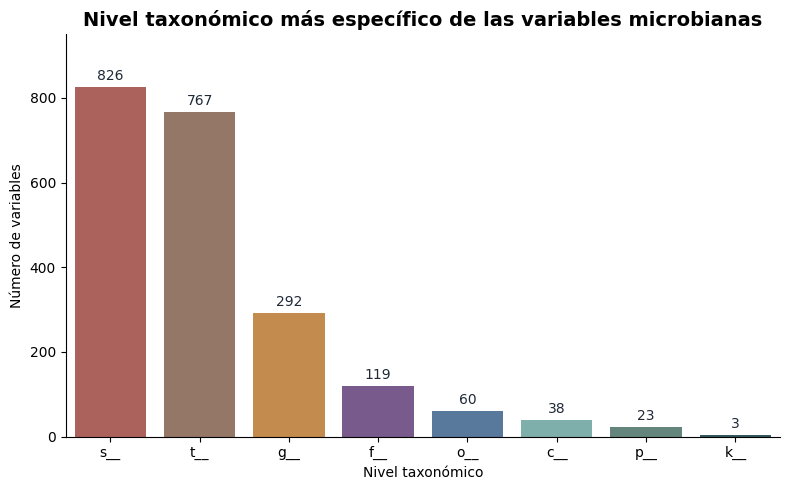

In [93]:
# Graficar niveles taxonómicos
plt.figure(figsize=(8, 5))

bar_colors = [
    taxonomic_level_palette.get(level, project_palette["neutral"])
    for level in taxonomic_level_counts.index
]

ax = sns.barplot(
    x=taxonomic_level_counts.index,
    y=taxonomic_level_counts.values,
    palette=bar_colors
)

for i, count in enumerate(taxonomic_level_counts.values):
    ax.text(
        i,
        count + 10,
        str(count),
        ha="center",
        va="bottom",
        fontsize=10,
        color=project_palette["dark"]
    )

plt.title("Nivel taxonómico más específico de las variables microbianas", fontsize=14, fontweight="bold")
plt.xlabel("Nivel taxonómico")
plt.ylabel("Número de variables")
plt.ylim(0, taxonomic_level_counts.max() * 1.15)

sns.despine()
plt.tight_layout()

# Guardar gráfico
plt.savefig(
    f"D:/BOOTCAMP/CARPETA_BARBARA/ML_MICROBIOME/ML/docs/figures/niveles_taxonomicos.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 6.2. *Sparcity* de las variables taxonómicas

**Sparsity**: condición en la que un conjunto de datos, una matriz o un modelo contiene una gran cantidad de elementos vacíos, nulos o con valor de cero.
<br>
En este caso en particular, revisar cuántos ceros hay en las **abundancias**.

In [ ]:
# Sparsity de las variables taxonómicas

X_taxa = df_eda[taxa_cols]      # dataframe solo con taxones

zero_percentage_by_taxon = (X_taxa == 0).mean().mul(100)        # máscara

zero_percentage_by_taxon.describe()

count    2128.000000
mean       86.851700
std        24.461694
min         0.000000
25%        89.109068
50%        98.858592
75%        99.873177
max       100.000000
dtype: float64

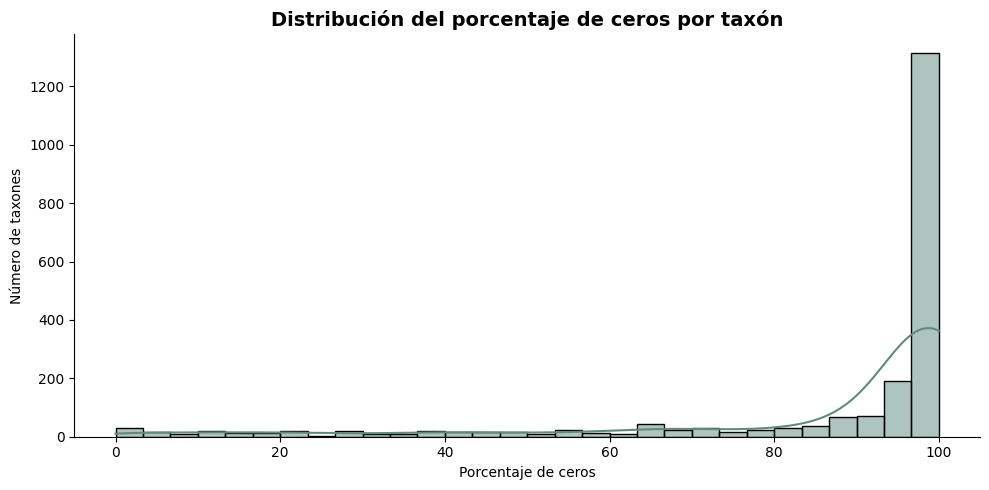

In [95]:
# Gráfico
plt.figure(figsize=(10, 5))

sns.histplot(
    zero_percentage_by_taxon,
    bins=30,
    kde=True,
    color=project_palette["secondary"]
)

plt.title("Distribución del porcentaje de ceros por taxón", fontsize=14, fontweight="bold")
plt.xlabel("Porcentaje de ceros")
plt.ylabel("Número de taxones")

sns.despine()
plt.tight_layout()

# Guardar gráfico
plt.savefig(
    f"D:/BOOTCAMP/CARPETA_BARBARA/ML_MICROBIOME/ML/docs/figures/sparcity_taxones.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

La distribución muestra una elevada sparsity en las variables taxonómicas: muchos taxones tienen valores cero en más del 90-95% de las muestras. Esto indica que gran parte de los taxones son poco prevalentes en la cohorte analizada. Esta característica es habitual en datos de microbioma y justifica aplicar estrategias posteriores de filtrado de baja prevalencia, agregación taxonómica o reducción de dimensionalidad antes del modelado.

### 6.3. Prevalencia de taxones según distintos umbrales

Cuantificar cuántos taxones conservar con distintos umbrales de prevalencia. Sirve para decidir después si es necesario filtrar.

In [ ]:
# Calcula en qué % de muestras aparece cada taxón
prevalence_by_taxon = (X_taxa > 0).mean().mul(100)

# Define posibles umbrales
prevalence_thresholds = [1, 5, 10, 20, 30, 50]

prevalence_filter_summary = pd.DataFrame({
    "prevalence_threshold_pct": prevalence_thresholds,
    "taxa_retained": [
        (prevalence_by_taxon >= threshold).sum()
        for threshold in prevalence_thresholds
    ]
})

prevalence_filter_summary

,prevalence_threshold_pct,taxa_retained
0,1,1107
1,5,713
2,10,555
3,20,420
4,30,349
5,50,227


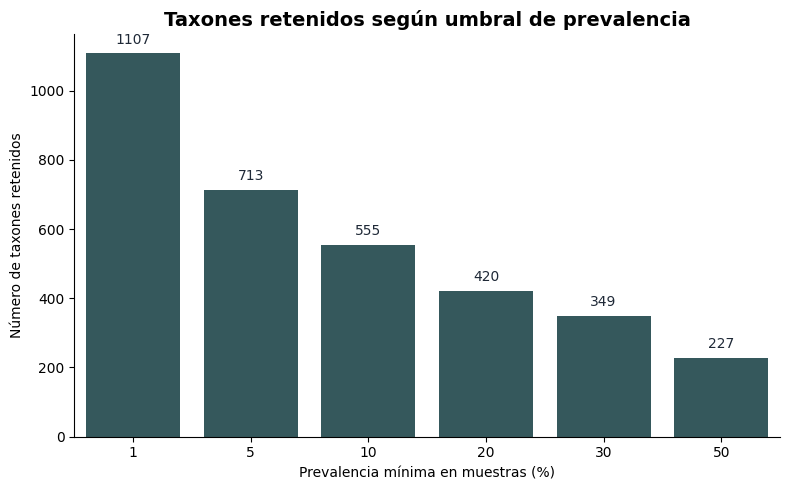

In [97]:
#Graficar
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=prevalence_filter_summary,
    x="prevalence_threshold_pct",
    y="taxa_retained",
    color=project_palette["primary"]
)

for i, row in prevalence_filter_summary.iterrows():
    ax.text(
        i,
        row["taxa_retained"] + 20,
        int(row["taxa_retained"]),
        ha="center",
        va="bottom",
        fontsize=10,
        color=project_palette["dark"]
    )

plt.title("Taxones retenidos según umbral de prevalencia", fontsize=14, fontweight="bold")
plt.xlabel("Prevalencia mínima en muestras (%)")
plt.ylabel("Número de taxones retenidos")

sns.despine()
plt.tight_layout()

# Guardar gráfico
plt.savefig(
    f"D:/BOOTCAMP/CARPETA_BARBARA/ML_MICROBIOME/ML/docs/figures/taxones_retenidos_prevalencia.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 6.4. Taxones más abundantes

In [ ]:
# Calcular la abundancia media de cada taxon en todas las muestras (y ordenar de mayor a menor)
mean_abundance_by_taxon = X_taxa.mean().sort_values(ascending=False)

# Top 20
top_n_taxa = 20

top_abundant_taxa = mean_abundance_by_taxon.head(top_n_taxa)

top_abundant_taxa

k__Bacteria                                                                                                                          99.197602
k__Bacteria|p__Firmicutes                                                                                                            45.145436
k__Bacteria|p__Bacteroidetes                                                                                                         44.546800
k__Bacteria|p__Bacteroidetes|c__Bacteroidia|o__Bacteroidales                                                                         44.537093
k__Bacteria|p__Bacteroidetes|c__Bacteroidia                                                                                          44.537093
k__Bacteria|p__Firmicutes|c__Clostridia                                                                                              37.954407
k__Bacteria|p__Firmicutes|c__Clostridia|o__Clostridiales                                                                             37.954366

In [99]:
# Función para editar el nombre de los taxones
def simplify_taxon_name(taxon_name):
    parts = taxon_name.split("|")
    deepest_part = parts[-1]
    return deepest_part

In [100]:
top_abundant_taxa_plot = pd.DataFrame({
    "taxon": top_abundant_taxa.index,
    "mean_abundance": top_abundant_taxa.values
})

top_abundant_taxa_plot["taxon_short"] = top_abundant_taxa_plot["taxon"].apply(
    simplify_taxon_name
)

top_abundant_taxa_plot

,taxon,mean_abundance,taxon_short
0,k__Bacteria,99.197602,k__Bacteria
1,k__Bacteria|p__Firmicutes,45.145436,p__Firmicutes
2,k__Bacteria|p__Bacteroidetes,44.546800,p__Bacteroidetes
3,k__Bacteria|p__Bacteroidetes|c__Bacteroidia|o_...,44.537093,o__Bacteroidales
4,k__Bacteria|p__Bacteroidetes|c__Bacteroidia,44.537093,c__Bacteroidia
5,k__Bacteria|p__Firmicutes|c__Clostridia,37.954407,c__Clostridia
6,k__Bacteria|p__Firmicutes|c__Clostridia|o__Clo...,37.954366,o__Clostridiales
7,k__Bacteria|p__Bacteroidetes|c__Bacteroidia|o_...,27.217505,f__Bacteroidaceae
8,k__Bacteria|p__Bacteroidetes|c__Bacteroidia|o_...,27.217505,g__Bacteroides
9,k__Bacteria|p__Firmicutes|c__Clostridia|o__Clo...,16.679208,f__Ruminococcaceae


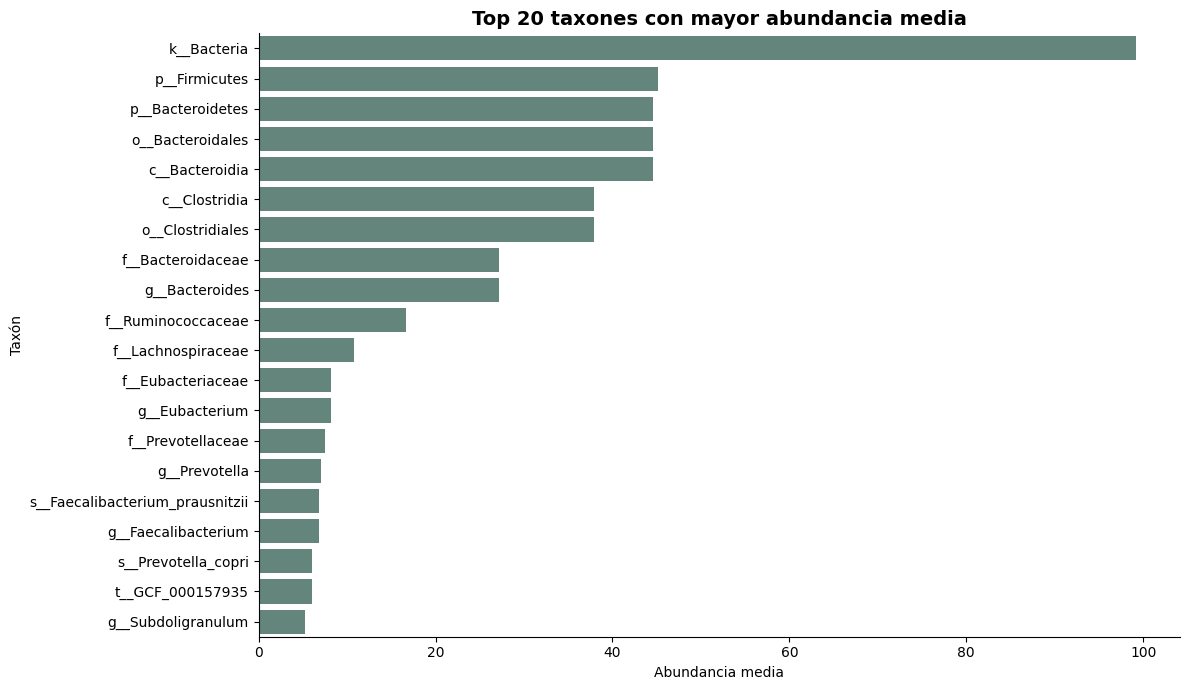

In [101]:
# Graficar
plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=top_abundant_taxa_plot,
    x="mean_abundance",
    y="taxon_short",
    color=project_palette["secondary"]
)

plt.title("Top 20 taxones con mayor abundancia media", fontsize=14, fontweight="bold")
plt.xlabel("Abundancia media")
plt.ylabel("Taxón")

sns.despine()
plt.tight_layout()

# Guardar gráfico
plt.savefig(
    f"D:/BOOTCAMP/CARPETA_BARBARA/ML_MICROBIOME/ML/docs/figures/top20_taxones_abundantes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 6.5. Taxones más variables

In [102]:
# Calcular la varianza de cada taxón y ordenar de mayor a menor
variance_by_taxon = X_taxa.var().sort_values(ascending=False)

# Top 20
top_n_variable_taxa = 20

top_variable_taxa = variance_by_taxon.head(top_n_variable_taxa)

top_variable_taxa

k__Bacteria|p__Bacteroidetes|c__Bacteroidia                                                                                          641.934009
k__Bacteria|p__Bacteroidetes|c__Bacteroidia|o__Bacteroidales                                                                         641.934009
k__Bacteria|p__Bacteroidetes                                                                                                         641.390597
k__Bacteria|p__Firmicutes                                                                                                            510.496732
k__Bacteria|p__Bacteroidetes|c__Bacteroidia|o__Bacteroidales|f__Bacteroidaceae                                                       487.957733
k__Bacteria|p__Bacteroidetes|c__Bacteroidia|o__Bacteroidales|f__Bacteroidaceae|g__Bacteroides                                        487.957733
k__Bacteria|p__Firmicutes|c__Clostridia                                                                                              450

In [103]:
top_variable_taxa_plot = pd.DataFrame({
    "taxon": top_variable_taxa.index,
    "variance": top_variable_taxa.values
})

top_variable_taxa_plot["taxon_short"] = top_variable_taxa_plot["taxon"].apply(
    simplify_taxon_name
)

top_variable_taxa_plot

,taxon,variance,taxon_short
0,k__Bacteria|p__Bacteroidetes|c__Bacteroidia,641.934009,c__Bacteroidia
1,k__Bacteria|p__Bacteroidetes|c__Bacteroidia|o_...,641.934009,o__Bacteroidales
2,k__Bacteria|p__Bacteroidetes,641.390597,p__Bacteroidetes
3,k__Bacteria|p__Firmicutes,510.496732,p__Firmicutes
4,k__Bacteria|p__Bacteroidetes|c__Bacteroidia|o_...,487.957733,f__Bacteroidaceae
5,k__Bacteria|p__Bacteroidetes|c__Bacteroidia|o_...,487.957733,g__Bacteroides
6,k__Bacteria|p__Firmicutes|c__Clostridia,450.870825,c__Clostridia
7,k__Bacteria|p__Firmicutes|c__Clostridia|o__Clo...,450.869344,o__Clostridiales
8,k__Bacteria|p__Bacteroidetes|c__Bacteroidia|o_...,248.082697,f__Prevotellaceae
9,k__Bacteria|p__Bacteroidetes|c__Bacteroidia|o_...,245.637952,g__Prevotella


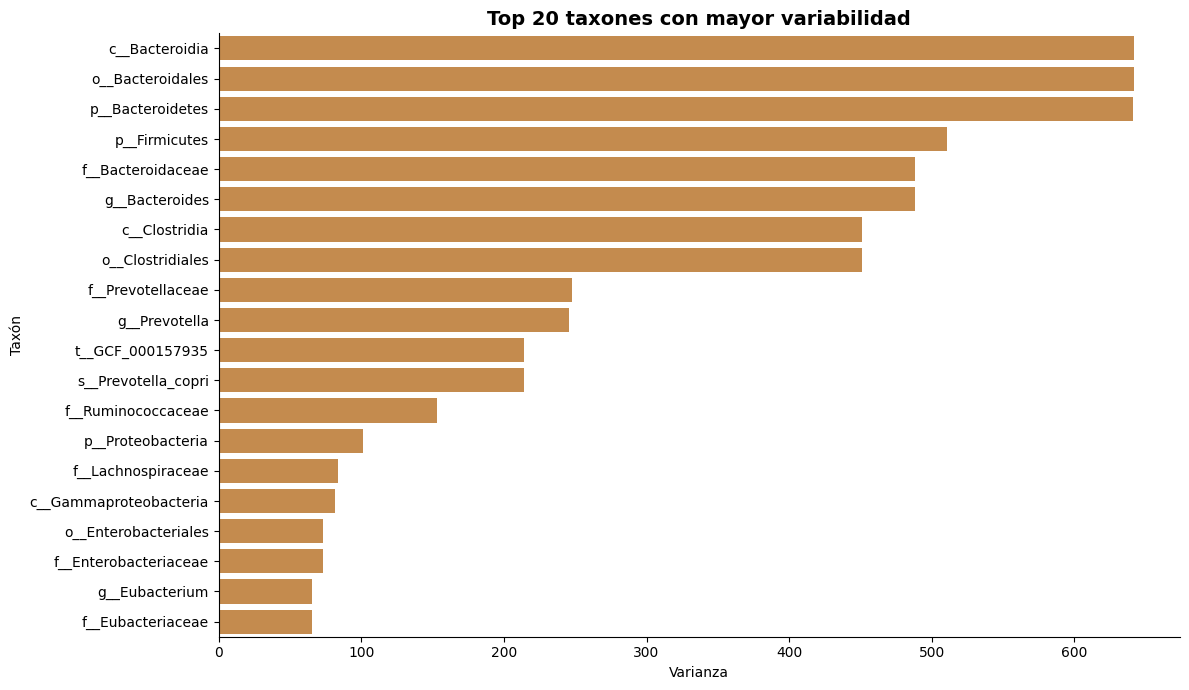

In [104]:
# Grafico
plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=top_variable_taxa_plot,
    x="variance",
    y="taxon_short",
    color=project_palette["accent"]
)

plt.title("Top 20 taxones con mayor variabilidad", fontsize=14, fontweight="bold")
plt.xlabel("Varianza")
plt.ylabel("Taxón")

sns.despine()
plt.tight_layout()

# Guardar gráfico
plt.savefig(
    f"D:/BOOTCAMP/CARPETA_BARBARA/ML_MICROBIOME/ML/docs/figures/top20_taxones_variables.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Los taxones con mayor abundancia media no son necesariamente los más útiles para diferenciar grupos clínicos. Por ello, también se analizaron los taxones con mayor variabilidad entre muestras, ya que podrían aportar más información para segmentación, PCA o modelado supervisado.

### 6.6 Agregar taxones por nivel taxonómico

In [ ]:
# Función para agregar taxones por nivel taxonómico
def extract_tax_level(taxon_name, level="p__"):
    parts = taxon_name.split("|")
    for part in parts:
        if part.startswith(level):
            return part
    return "unknown"

In [106]:
# Función para agregar abundancias
def aggregate_taxa_by_level(df_taxa, level="p__"):
    grouped_taxa_names = [
        extract_tax_level(col, level=level)
        for col in df_taxa.columns
    ]

    df_grouped = df_taxa.T.groupby(grouped_taxa_names).sum().T

    if "unknown" in df_grouped.columns:
        df_grouped = df_grouped.drop(columns=["unknown"])

    return df_grouped

In [107]:
# Aplicado a filo y clase
X_phylum = aggregate_taxa_by_level(X_taxa, level="p__")
X_class = aggregate_taxa_by_level(X_taxa, level="c__")

print("Taxones originales:", X_taxa.shape[1])
print("Filos:", X_phylum.shape[1])
print("Clases:", X_class.shape[1])

Taxones originales: 2128
Filos: 23
Clases: 38
